Experiment 1 from the thesis

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.special import logsumexp

# X_train
n_train = 50
X_train = np.random.normal(0, 1, n_train)

# Y = sinc(X) + noise
sigma_noise = 0.25
Y_train = np.sinc(X_train) + np.random.normal(0, sigma_noise, n_train)

# X_test
n_test = 100
X_test = np.random.normal(0.5, 0.3, n_test)

Y_test = np.sinc(X_test) + np.random.normal(0, sigma_noise, n_test)

# w_i
def compute_weights(X_train, mu_train=0, sigma_train=1, mu_test=0.5, sigma_test=0.3):
    p_train = norm.pdf(X_train, mu_train, sigma_train)
    p_test = norm.pdf(X_train, mu_test, sigma_test)
    return p_test / p_train

weights = compute_weights(X_train)


In [2]:

# use a linear model
def predict(X, theta):
    return theta[0] + theta[1] * X

# for single observation
def log_likelihood(y, x, theta, sigma=sigma_noise):
    y_pred = predict(x, theta)
    return norm.logpdf(y, y_pred, sigma)

# prior: Normal on both parameters
def log_prior(theta, mu=0, sigma=1):
    return np.sum(norm.logpdf(theta, mu, sigma))


lambda_tilt = 1.0
# score function for quasi-posterior
def score_function(y, x, theta, weight, lambda_tilt=lambda_tilt):
    return weight**lambda_tilt * log_likelihood(y, x, theta)

def log_quasi_posterior(theta, Y, X, weights, lambda_tilt):
    log_qp = log_prior(theta)
    for i in range(len(Y)):
        log_qp += score_function(Y[i], X[i], theta, weights[i], lambda_tilt)
    return log_qp

# Sample from quasi-posterior (Metropolis-Hastings)
def sample_quasi_posterior(Y, X, weights, lambda_tilt, num_samples=7000, burn_in=100):
    theta = np.array([0.0, 0.0])  # initial value
    samples = []
    for i in range(num_samples + burn_in):
        # Propose new theta
        theta_new = theta + np.random.normal( loc=0, scale=0.35, size=2 )
        
        # Acceptance ratio
        log_alpha = (
            log_quasi_posterior(theta_new, Y, X, weights, lambda_tilt) - 
            log_quasi_posterior(theta,     Y, X, weights, lambda_tilt)
        )
        
        # Accept/reject
        if np.log(np.random.rand()) < log_alpha:
            theta = theta_new
        
        if i >= burn_in:
            samples.append(theta)
    
    return np.array(samples)

# Sample from quasi-posterior
posterior_samples = sample_quasi_posterior(Y_train, X_train, weights, lambda_tilt)
print(f"Sampled {len(posterior_samples)} posterior samples")
print(f"Posterior mean: {posterior_samples.mean(axis=0)}")
print(f"OLS: {np.polyfit(X_train, Y_train, deg=1)[::-1]}")


def compute_pcic(Y, X, weights, posterior_samples, lambda_tilt):
    n = len(Y)
    term1 = term2 = 0
    
    for i in range(n):
        log_liks = np.array([log_likelihood(Y[i], X[i], theta) for theta in posterior_samples])
 
        log_expectation = logsumexp(log_liks) - np.log(len(posterior_samples))
        term1 -= weights[i] * log_expectation
        
        scores = np.array([score_function(Y[i], X[i], theta, weights[i], lambda_tilt) for theta in posterior_samples])
        cov = np.mean((log_liks - np.mean(log_liks)) * (scores - np.mean(scores)))
        term2 += weights[i] * cov
    
    pcic = (term1 + term2) / n
    return pcic, term1, term2

Sampled 7000 posterior samples
Posterior mean: [ 1.02093081 -1.00517657]
OLS: [ 0.39617033 -0.04993689]


In [3]:
pcic, term1, term2 = compute_pcic(Y_train, X_train, weights, posterior_samples, lambda_tilt)
print(f"\nPCIC = {pcic:.4f}")
print(f"  training loss: {term1:.4f}")
print(f"  correction: {term2:.4f}")

def compute_generalization_error(X_test, Y_test, posterior_samples):
    n_test = len(X_test)
    gen_error = 0
    
    for i in range(n_test):
        log_liks = np.array([
            log_likelihood(Y_test[i], X_test[i], theta) for theta in posterior_samples
        ])
        log_pred_density = logsumexp(log_liks) - np.log(len(posterior_samples))
        gen_error -= log_pred_density
    
    return gen_error / n_test

gen_error = compute_generalization_error(X_test, Y_test, posterior_samples)
print(f"True generalization error: {gen_error:.4f}")


PCIC = 0.0381
  training loss: -1.5042
  correction: 3.4071
True generalization error: 0.0614


In [4]:
lambda_values = np.linspace(0, 1.6, 9)

posterior_dict = {}

for lam in lambda_values:
    print(f"sampling posterior for lambda = {lam:.2f}")
    
    posterior_dict[lam] = sample_quasi_posterior(
        Y_train,
        X_train,
        weights,
        lambda_tilt=lam,
        num_samples=2000,
        burn_in=200
    )

sampling posterior for lambda = 0.00
sampling posterior for lambda = 0.20
sampling posterior for lambda = 0.40
sampling posterior for lambda = 0.60
sampling posterior for lambda = 0.80
sampling posterior for lambda = 1.00
sampling posterior for lambda = 1.20
sampling posterior for lambda = 1.40
sampling posterior for lambda = 1.60


In [5]:
import matplotlib.pyplot as plt

def compute_waic(Y, X, posterior_samples):
    total = 0
    
    for i in range(len(Y)):
        log_liks = np.array([log_likelihood(Y[i], X[i], theta) for theta in posterior_samples])
        log_expectation = logsumexp(log_liks) - np.log(len(posterior_samples))
        variance = np.var(log_liks)
        total += variance - log_expectation

    return total / len(Y)

pcic_values = []
waic_values = []
gen_error_values = []

for lam in lambda_values:
    posterior_samples = posterior_dict[lam]
    
    # PCIC
    pcic, _, _ = compute_pcic(
        Y_train, X_train, weights, posterior_samples, lam
    )
    pcic_values.append(pcic)
    
    # WAIC (no weights)
    waic = compute_waic(
        Y_train, X_train, posterior_samples
    )
    waic_values.append(waic)
    
    gen_error = compute_generalization_error(
        X_test, Y_test, posterior_samples
    )
    gen_error_values.append(gen_error)

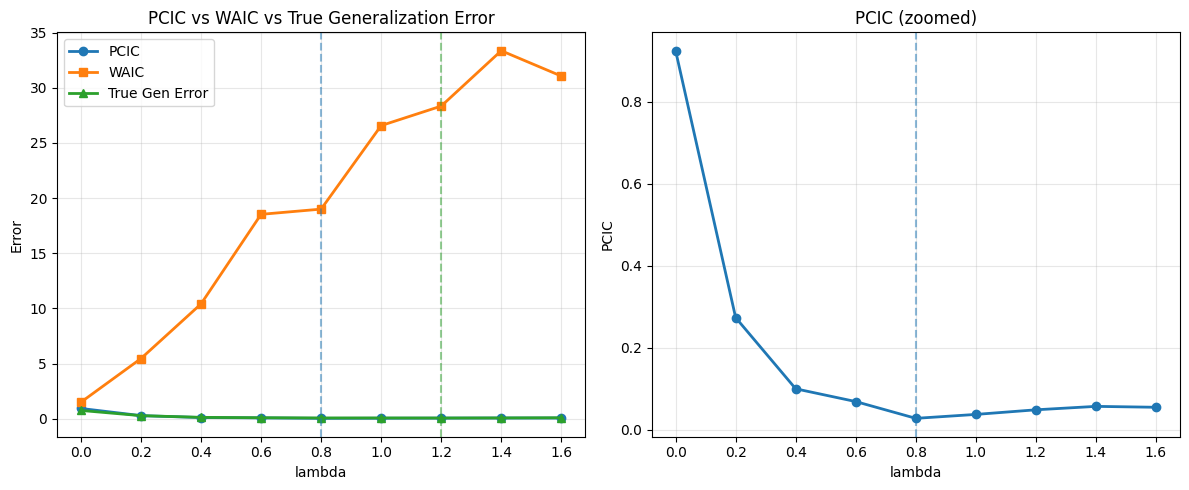

best lambda according to PCIC: 0.80
best lambda according to WAIC: 0.00
best lambda according to true gen error: 1.20


In [6]:
# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lambda_values, pcic_values, 'o-', label='PCIC', linewidth=2)
plt.plot(lambda_values, waic_values, 's-', label='WAIC', linewidth=2)
plt.plot(lambda_values, gen_error_values, '^-', label='True Gen Error', linewidth=2)
plt.xlabel('lambda')
plt.ylabel('Error')
plt.title('PCIC vs WAIC vs True Generalization Error')
plt.legend()
plt.grid(True, alpha=0.3)

best_lambda_pcic = lambda_values[np.argmin(pcic_values)]
best_lambda_waic = lambda_values[np.argmin(waic_values)]
best_lambda_true = lambda_values[np.argmin(gen_error_values)]

plt.axvline(best_lambda_pcic, color='C0', linestyle='--', alpha=0.5, label=f'best PCIC: lambda={best_lambda_pcic:.2f}')
plt.axvline(best_lambda_true, color='C2', linestyle='--', alpha=0.5, label=f'best True: lambda={best_lambda_true:.2f}')

plt.subplot(1, 2, 2)
plt.plot(lambda_values, pcic_values, 'o-', linewidth=2, color='C0')
plt.xlabel('lambda')
plt.ylabel('PCIC')
plt.title('PCIC (zoomed)')
plt.grid(True, alpha=0.3)
plt.axvline(best_lambda_pcic, color='C0', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"best lambda according to PCIC: {best_lambda_pcic:.2f}")
print(f"best lambda according to WAIC: {best_lambda_waic:.2f}")
print(f"best lambda according to true gen error: {best_lambda_true:.2f}")